<a href="https://colab.research.google.com/github/Dnyamwamu/neural_nets/blob/main/Notebooks/Chap06/6_3_Stochastic_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 6.3: Stochastic gradient descent**

This notebook investigates gradient descent and stochastic gradient descent and recreates figure 6.5 from the book

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.





In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

In [2]:
# Let's create our training data of 30 pairs {x_i, y_i}
# We'll try to fit the Gabor model to these data
data = np.array([[-1.920e+00,-1.422e+01,1.490e+00,-1.940e+00,-2.389e+00,-5.090e+00,
                 -8.861e+00,3.578e+00,-6.010e+00,-6.995e+00,3.634e+00,8.743e-01,
                 -1.096e+01,4.073e-01,-9.467e+00,8.560e+00,1.062e+01,-1.729e-01,
                  1.040e+01,-1.261e+01,1.574e-01,-1.304e+01,-2.156e+00,-1.210e+01,
                 -1.119e+01,2.902e+00,-8.220e+00,-1.179e+01,-8.391e+00,-4.505e+00],
                  [-1.051e+00,-2.482e-02,8.896e-01,-4.943e-01,-9.371e-01,4.306e-01,
                  9.577e-03,-7.944e-02 ,1.624e-01,-2.682e-01,-3.129e-01,8.303e-01,
                  -2.365e-02,5.098e-01,-2.777e-01,3.367e-01,1.927e-01,-2.222e-01,
                  6.352e-02,6.888e-03,3.224e-02,1.091e-02,-5.706e-01,-5.258e-02,
                  -3.666e-02,1.709e-01,-4.805e-02,2.008e-01,-1.904e-01,5.952e-01]])

In [3]:
# Let's define our model
def model(phi,x):
  sin_component = np.sin(phi[0] + 0.06 * phi[1] * x)
  gauss_component = np.exp(-(phi[0] + 0.06 * phi[1] * x) * (phi[0] + 0.06 * phi[1] * x) / 32)
  y_pred= sin_component * gauss_component
  return y_pred

In [4]:
# Draw model
def draw_model(data,model,phi,title=None):
  x_model = np.arange(-15,15,0.1)
  y_model = model(phi,x_model)

  fix, ax = plt.subplots()
  ax.plot(data[0,:],data[1,:],'bo')
  ax.plot(x_model,y_model,'m-')
  ax.set_xlim([-15,15]);ax.set_ylim([-1,1])
  ax.set_xlabel('x'); ax.set_ylabel('y')
  if title is not None:
    ax.set_title(title)
  plt.show()

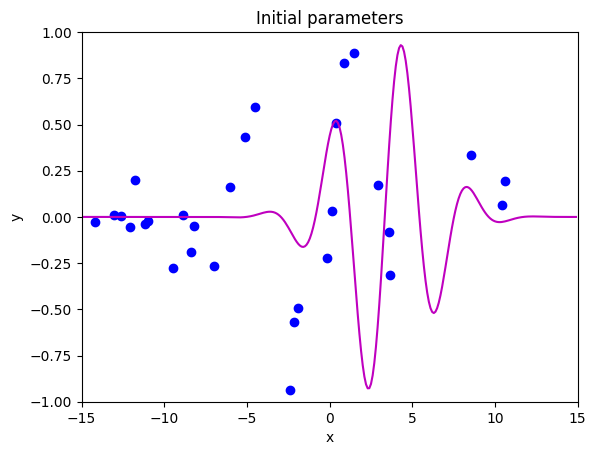

In [5]:
# Initialize the parameters and draw the model
phi = np.zeros((2,1))
phi[0] =  -5     # Horizontal offset
phi[1] =  25     # Frequency
draw_model(data,model,phi, "Initial parameters")


Now let's compute the sum of squares loss for the training data

In [6]:
def compute_loss(data_x, data_y, model, phi):
  # 1. Make predictions using the model
  pred_y = model(phi, data_x)

  # 2. Compute squared differences
  squared_error = (pred_y - data_y) ** 2

  # 3. Sum them to get total loss
  loss = np.sum(squared_error)

  return loss

Let's just test that we got that right

In [7]:
loss = compute_loss(data[0,:],data[1,:],model,np.array([[0.6],[-0.2]]))
print('Your loss = %3.3f, Correct loss = %3.3f'%(loss, 16.419))

Your loss = 16.419, Correct loss = 16.419


Now let's plot the whole loss function

In [8]:
def draw_loss_function(compute_loss, data,  model, phi_iters = None):
  # Define pretty colormap
  my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
  my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
  r = np.floor(my_colormap_vals_dec/(256*256))
  g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
  b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
  my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

  # Make grid of offset/frequency values to plot
  offsets_mesh, freqs_mesh = np.meshgrid(np.arange(-10,10.0,0.1), np.arange(2.5,22.5,0.1))
  loss_mesh = np.zeros_like(freqs_mesh)
  # Compute loss for every set of parameters
  for idslope, slope in np.ndenumerate(freqs_mesh):
     loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[offsets_mesh[idslope]], [slope]]))

  fig,ax = plt.subplots()
  fig.set_size_inches(8,8)
  ax.contourf(offsets_mesh,freqs_mesh,loss_mesh,256,cmap=my_colormap)
  ax.contour(offsets_mesh,freqs_mesh,loss_mesh,20,colors=['#80808080'])
  if phi_iters is not None:
    ax.plot(phi_iters[0,:], phi_iters[1,:],'go-')
  ax.set_ylim([2.5,22.5])
  ax.set_xlabel('Offset $\phi_{0}$'); ax.set_ylabel('Frequency, $\phi_{1}$')
  plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1198/2328334872.py:24: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('Offset $\phi_{0}$'); ax.set_ylabel('Frequency, $\phi_{1}$')
/tmp/ipykernel_1198/2328334872.py:24: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('Offset $\phi_{0}$'); ax.set_ylabel('Frequency, $\phi_{1}$')


In [ ]:
draw_loss_function(compute_loss, data, model)

Now let's compute the gradient vector for a given set of parameters:

\begin{equation}
\frac{\partial L}{\partial \boldsymbol\phi} = \begin{bmatrix}\frac{\partial L}{\partial \phi_0} \\\frac{\partial L}{\partial \phi_1} \end{bmatrix}.
\end{equation}

In [9]:
# These came from writing out the expression for the sum of squares loss and taking the
# derivative with respect to phi0 and phi1. It was a lot of hassle to get it right!
def gabor_deriv_phi0(data_x,data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = cos_component * gauss_component - sin_component * gauss_component * x / 16
    deriv = 2* deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def gabor_deriv_phi1(data_x, data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = 0.06 * data_x * cos_component * gauss_component - 0.06 * data_x*sin_component * gauss_component * x / 16
    deriv = 2*deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def compute_gradient(data_x, data_y, phi):
    dl_dphi0 = gabor_deriv_phi0(data_x, data_y, phi[0],phi[1])
    dl_dphi1 = gabor_deriv_phi1(data_x, data_y, phi[0],phi[1])
    # Return the gradient
    return np.array([[dl_dphi0],[dl_dphi1]])

We can check we got this right using a trick known as **finite differences**.  If we evaluate the function and then change one of the parameters by a very small amount and normalize by that amount, we get an approximation to the gradient, so:

\begin{align}
\frac{\partial L}{\partial \phi_{0}}&\approx & \frac{L[\phi_0+\delta, \phi_1]-L[\phi_0, \phi_1]}{\delta}\\
\frac{\partial L}{\partial \phi_{1}}&\approx & \frac{L[\phi_0, \phi_1+\delta]-L[\phi_0, \phi_1]}{\delta}
\end{align}

We can't do this when there are many parameters;  for a million parameters, we would have to evaluate the loss function two million times, and usually computing the gradients directly is much more efficient.

In [10]:
# Compute the gradient using your function
gradient = compute_gradient(data[0,:],data[1,:], phi)
print("Your gradients: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))
# Approximate the gradients with finite differences
delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Approx gradients: (%3.3f,%3.3f)"%(dl_dphi0_est,dl_dphi1_est))


Your gradients: (3.344,0.519)
Approx gradients: (3.344,0.519)


/tmp/ipykernel_1198/330192272.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Your gradients: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))


Now we are ready to perform gradient descent.  We'll need to use our line search routine from Notebook 6.1, which I've reproduced here plus the helper function loss_function_1D that converts from a 2D problem to a 1D problem

In [11]:
def loss_function_1D(dist_prop, data, model, phi_start, gradient):
  # Return the loss after moving this far
  return compute_loss(data[0,:], data[1,:], model, phi_start+ gradient * dist_prop)

def line_search(data, model, phi, gradient, thresh=.00001, max_dist = 0.1, max_iter = 15, verbose=False):
    # Initialize four points along the range we are going to search
    a = 0
    b = 0.33 * max_dist
    c = 0.66 * max_dist
    d = 1.0 * max_dist
    n_iter = 0

    # While we haven't found the minimum closely enough
    while np.abs(b-c) > thresh and n_iter < max_iter:
        # Increment iteration counter (just to prevent an infinite loop)
        n_iter = n_iter+1
        # Calculate all four points
        lossa = loss_function_1D(a, data, model, phi,gradient)
        lossb = loss_function_1D(b, data, model, phi,gradient)
        lossc = loss_function_1D(c, data, model, phi,gradient)
        lossd = loss_function_1D(d, data, model, phi,gradient)

        if verbose:
          print('Iter %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))
          print('a %f, b%f, c%f, d%f'%(lossa,lossb,lossc,lossd))

        # Rule #1 If point A is less than points B, C, and D then change B,C,D so they are half their current distance from A
        if np.argmin((lossa,lossb,lossc,lossd))==0:
          b = a+ (b-a)/2
          c = a+ (c-a)/2
          d = a+ (d-a)/2
          continue;

        # Rule #2 If point b is less than point c then
        #                     point d becomes point c, and
        #                     point b becomes 1/3 between a and new d
        #                     point c becomes 2/3 between a and new d
        if lossb < lossc:
          d = c
          b = a+ (d-a)/3
          c = a+ 2*(d-a)/3
          continue

        # Rule #2 If point c is less than point b then
        #                     point a becomes point b, and
        #                     point b becomes 1/3 between new a and d
        #                     point c becomes 2/3 between new a and d
        a = b
        b = a+ (d-a)/3
        c = a+ 2*(d-a)/3

    # Return average of two middle points
    return (b+c)/2.0

In [13]:
def gradient_descent_step(phi, data,  model):
  # Step 1:  Compute the gradient
  gradient = compute_gradient(data[0,:],data[1,:], phi)
  # Step 2:  Update the parameters -- note we want to search in the negative (downhill direction)
  alpha = line_search(data, model, phi, gradient*-1, max_dist = 2.0)
  phi = phi - alpha * gradient
  return phi

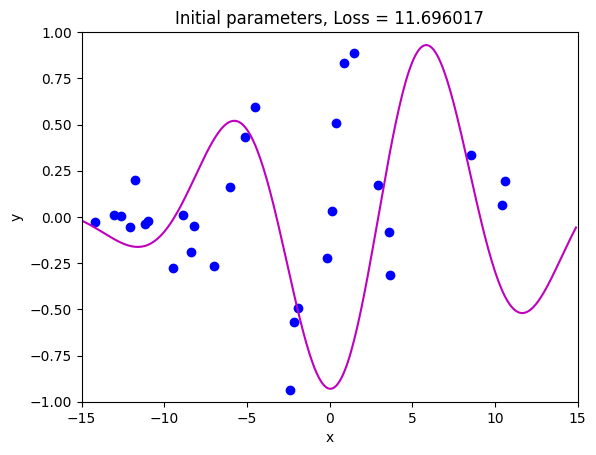

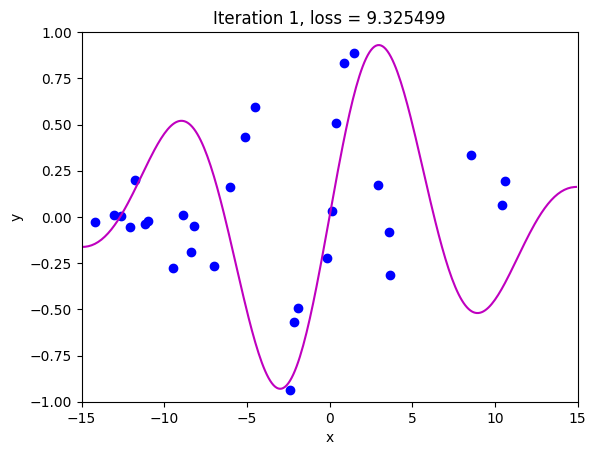

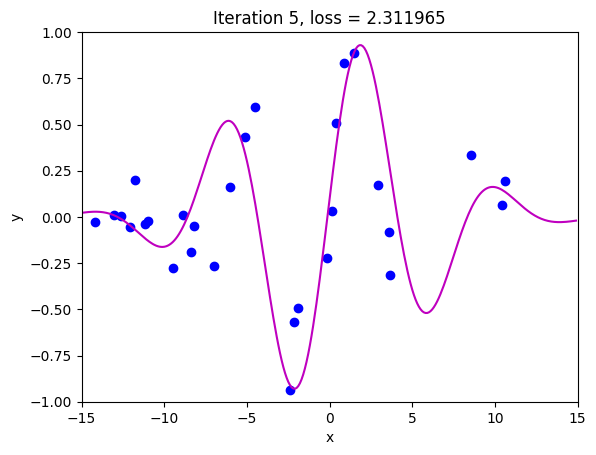

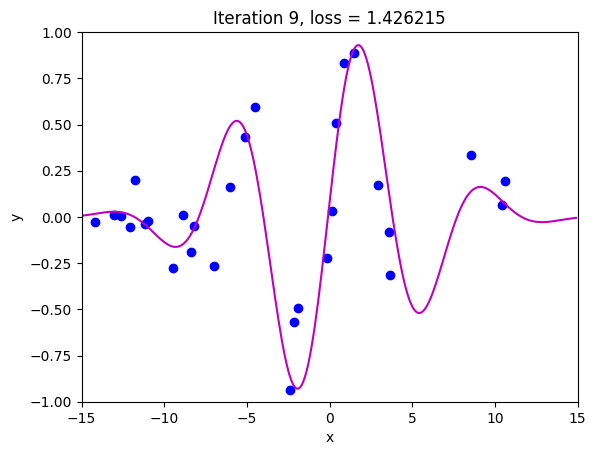

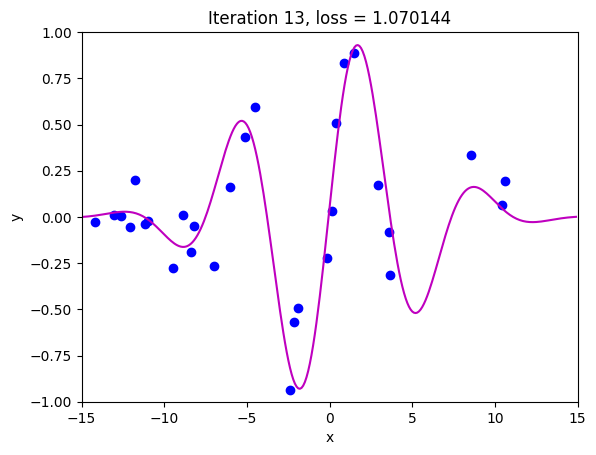

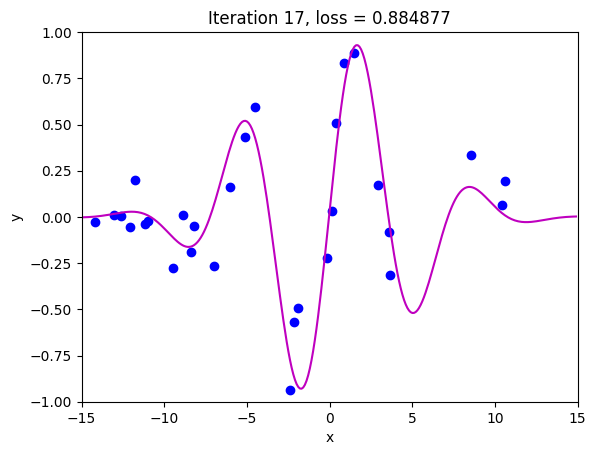

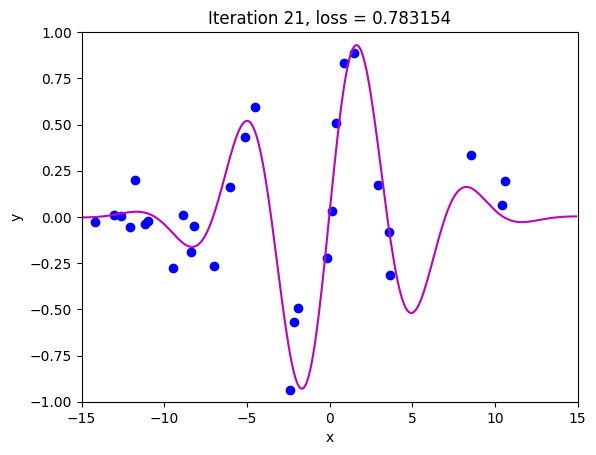

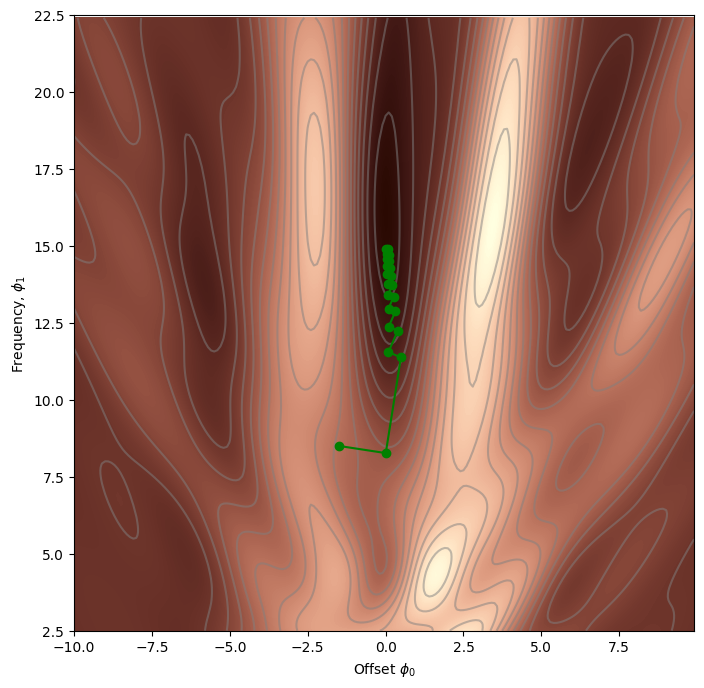

In [14]:
# Initialize the parameters
n_steps = 21
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = -1.5
phi_all[1,0] = 8.5

# Measure loss and draw initial model
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Initial parameters, Loss = %f"%(loss))

for c_step in range (n_steps):
  # Do gradient descent step
  phi_all[:,c_step+1:c_step+2] = gradient_descent_step(phi_all[:,c_step:c_step+1],data, model)
  # Measure loss and draw model every 4th step
  if c_step % 4 == 0:
    loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
    draw_model(data,model,phi_all[:,c_step+1], "Iteration %d, loss = %f"%(c_step+1,loss))

draw_loss_function(compute_loss, data, model,phi_all)


In [15]:
def compute_gradient(data_x, data_y, phi):
    delta = 0.0001

    # Current loss
    base_loss = compute_loss(data_x, data_y, model, phi)

    # Gradient w.r.t phi0
    phi0_shift = phi + np.array([[delta],[0]])
    dl_dphi0 = (compute_loss(data_x, data_y, model, phi0_shift) - base_loss) / delta

    # Gradient w.r.t phi1
    phi1_shift = phi + np.array([[0],[delta]])
    dl_dphi1 = (compute_loss(data_x, data_y, model, phi1_shift) - base_loss) / delta

    return np.array([[dl_dphi0],[dl_dphi1]])

In [16]:
def gradient_descent_step_fixed_learning_rate(phi, data, alpha):
  # Step 1: Compute gradient
  gradient = compute_gradient(data[0,:], data[1,:], phi)

  # Step 2: Update parameters using fixed learning rate
  phi = phi - alpha * gradient

  return phi

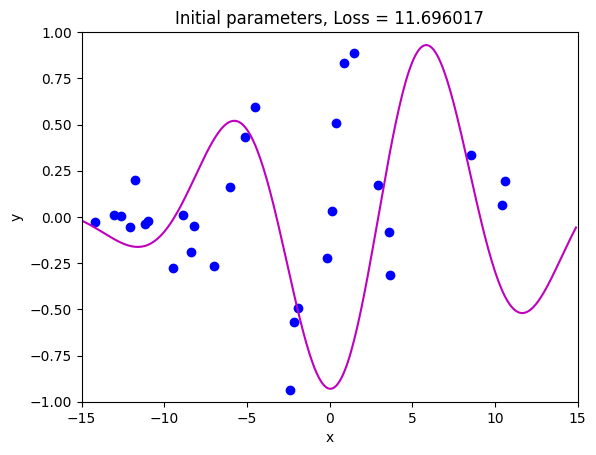

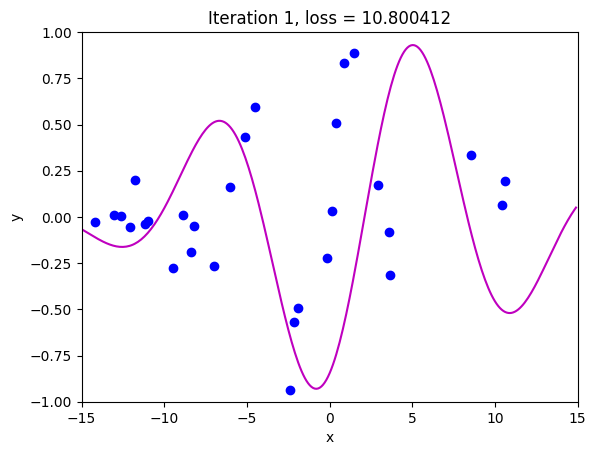

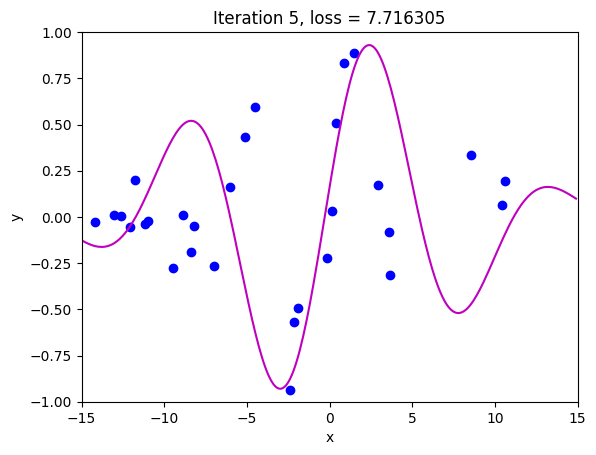

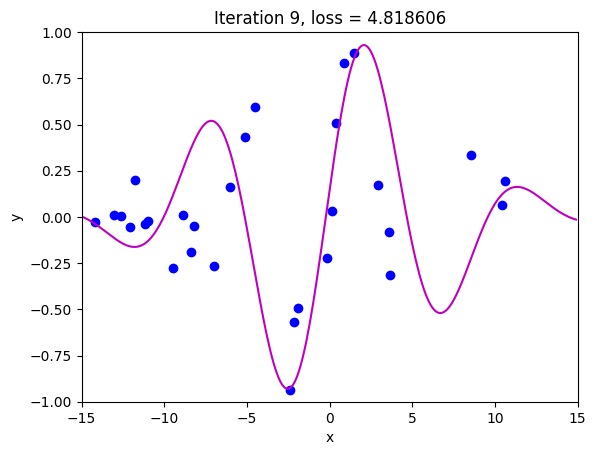

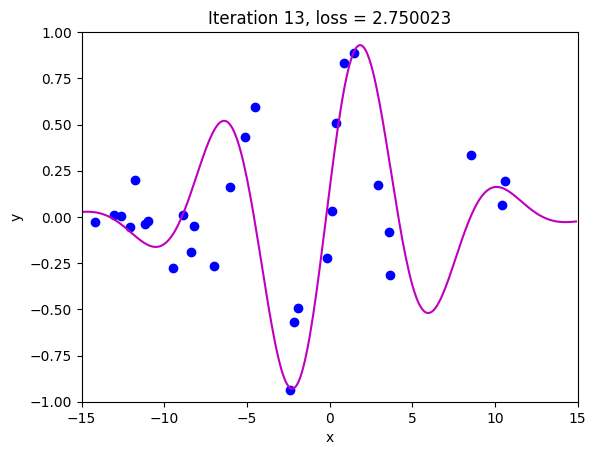

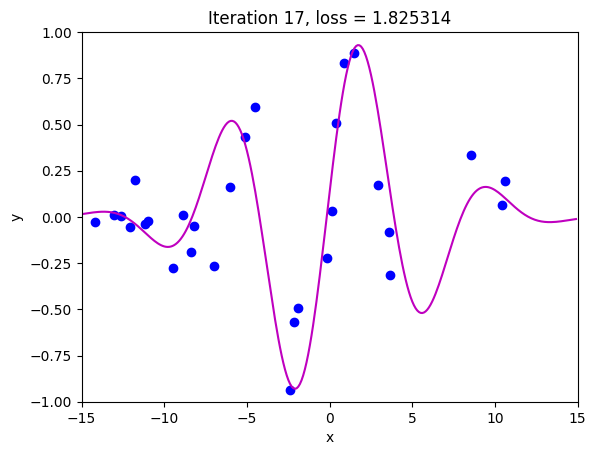

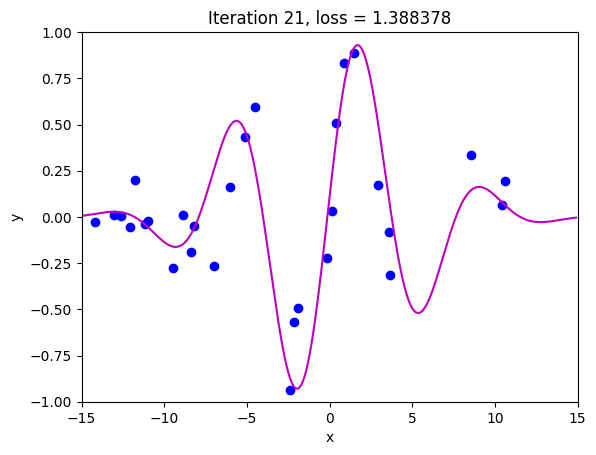

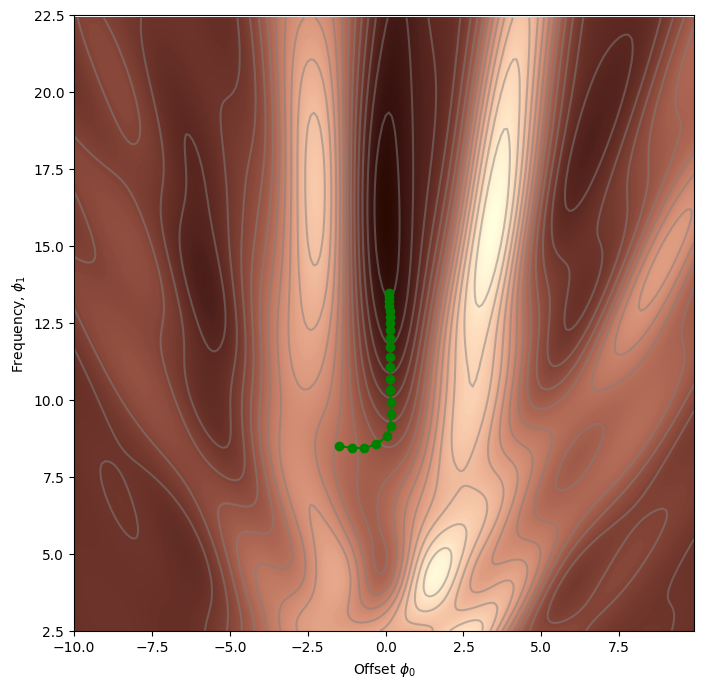

In [17]:
# Initialize the parameters
n_steps = 21
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = -1.5
phi_all[1,0] = 8.5

# Measure loss and draw initial model
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Initial parameters, Loss = %f"%(loss))

for c_step in range (n_steps):
  # Do gradient descent step
  phi_all[:,c_step+1:c_step+2] = gradient_descent_step_fixed_learning_rate(phi_all[:,c_step:c_step+1],data, alpha =0.2)
  # Measure loss and draw model every 4th step
  if c_step % 4 == 0:
    loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
    draw_model(data,model,phi_all[:,c_step+1], "Iteration %d, loss = %f"%(c_step+1,loss))

draw_loss_function(compute_loss, data, model,phi_all)


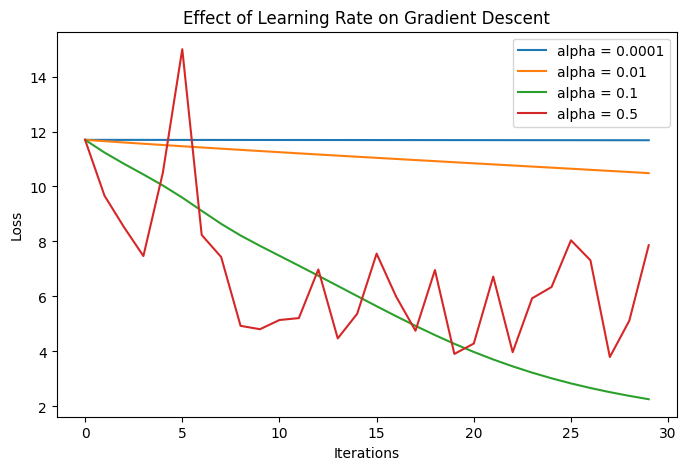

In [18]:
# Experiment with different learning rates
import numpy as np
import matplotlib.pyplot as plt

# Gradient descent with fixed learning rate
def gradient_descent_step_fixed_learning_rate(phi, data, model, alpha):
    gradient = compute_gradient(data[0,:], data[1,:], phi)
    phi = phi - alpha * gradient
    return phi

# Function to run gradient descent and record loss
def run_gradient_descent(alpha, steps=30):
    phi = np.array([[-1.5],[8.5]])   # starting parameters
    losses = []

    for i in range(steps):
        loss = compute_loss(data[0,:], data[1,:], model, phi)
        losses.append(loss)
        phi = gradient_descent_step_fixed_learning_rate(phi, data, model, alpha)

    return losses

# Learning rates to test
learning_rates = [0.0001, 0.01, 0.1, 0.5]

plt.figure(figsize=(8,5))

for alpha in learning_rates:
    losses = run_gradient_descent(alpha)
    plt.plot(losses, label=f'alpha = {alpha}')

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Gradient Descent")
plt.legend()
plt.show()

In [19]:
def stochastic_gradient_descent_step(phi, data, alpha, batch_size):

  # Number of data points
  n_data = data.shape[1]

  # Generate random permutation of indices
  indices = np.random.permutation(n_data)

  # Select a mini-batch
  batch_indices = indices[:batch_size]

  # Extract batch data
  batch_x = data[0, batch_indices]
  batch_y = data[1, batch_indices]

  # Compute gradient using the mini-batch
  gradient = compute_gradient(batch_x, batch_y, phi)

  # Update parameters
  phi = phi - alpha * gradient

  return phi

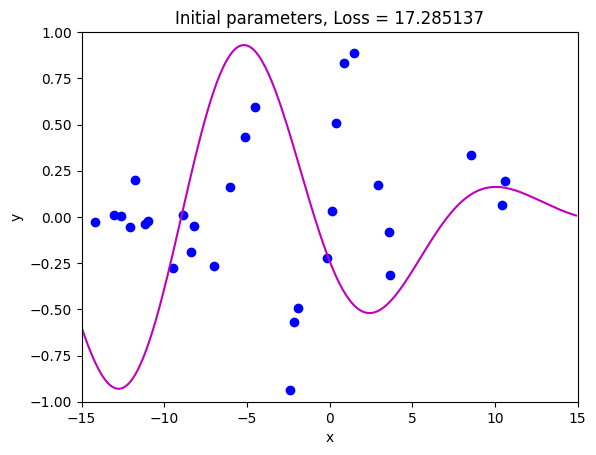

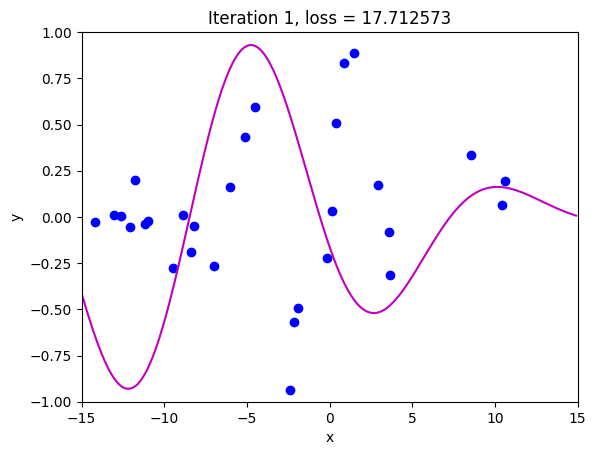

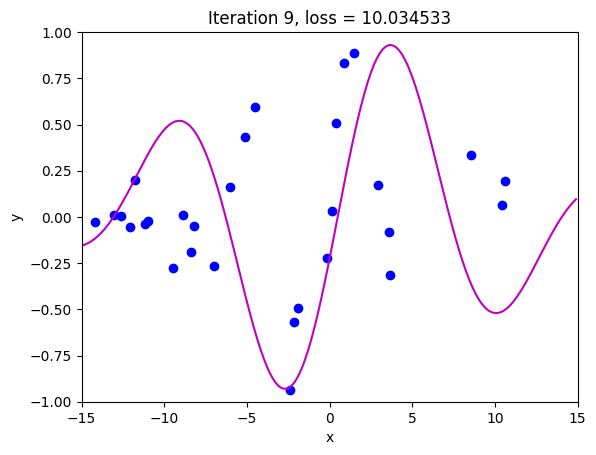

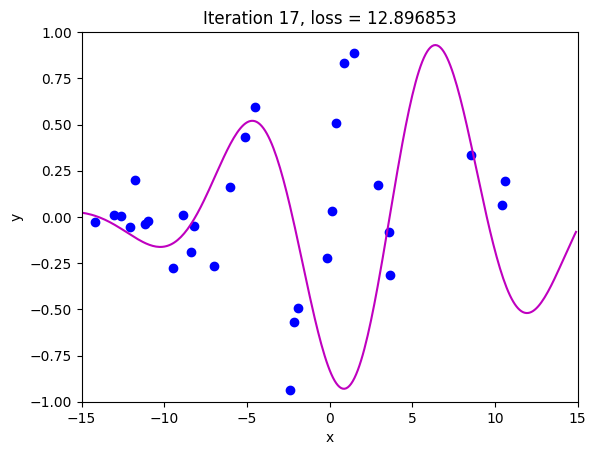

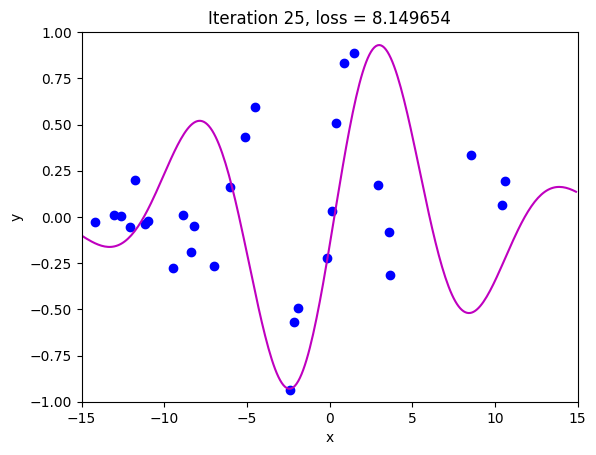

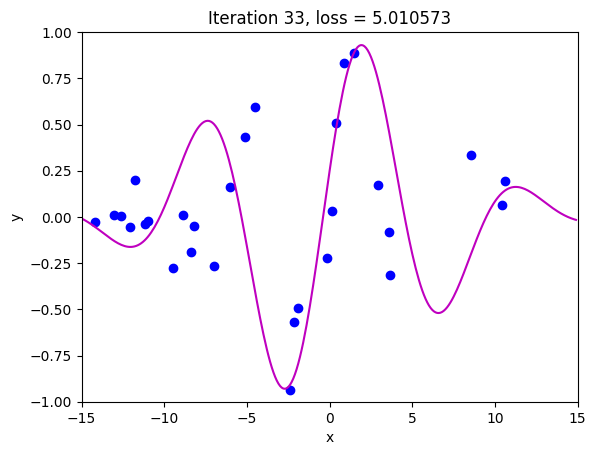

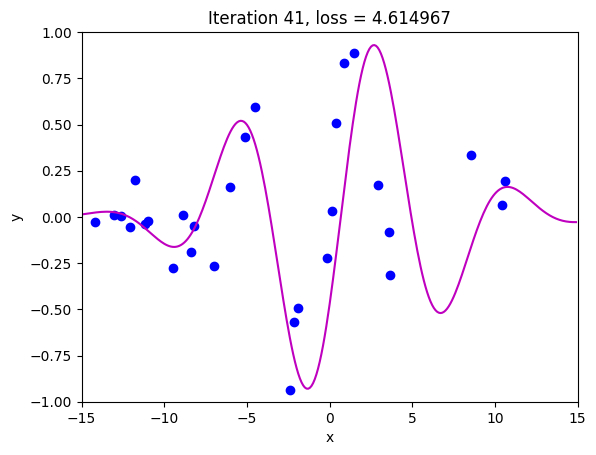

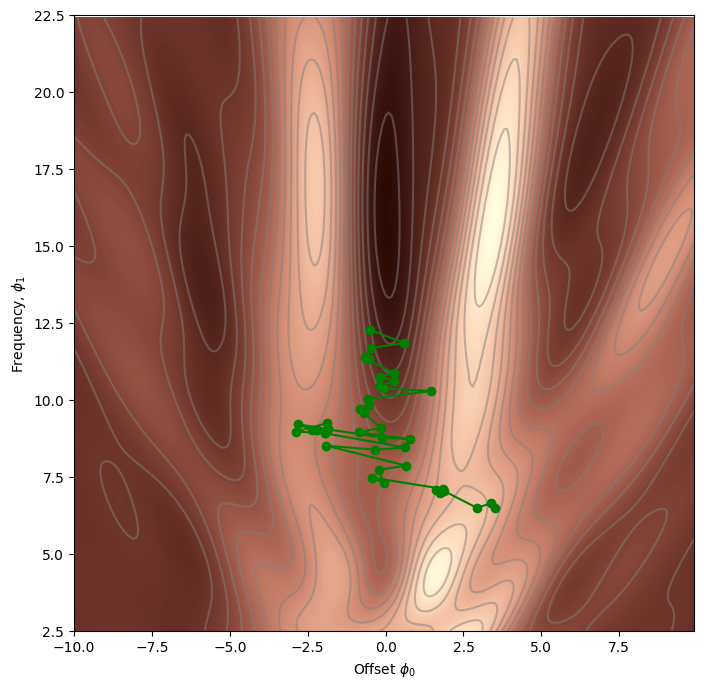

In [20]:
# Set the random number generator so you always get same numbers (disable if you don't want this)
np.random.seed(1)
# Initialize the parameters
n_steps = 41
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = 3.5
phi_all[1,0] = 6.5

# Measure loss and draw initial model
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Initial parameters, Loss = %f"%(loss))

for c_step in range (n_steps):
  # Do gradient descent step
  phi_all[:,c_step+1:c_step+2] = stochastic_gradient_descent_step(phi_all[:,c_step:c_step+1],data, alpha =0.8, batch_size=5)
  # Measure loss and draw model every 8th step
  if c_step % 8 == 0:
    loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
    draw_model(data,model,phi_all[:,c_step+1], "Iteration %d, loss = %f"%(c_step+1,loss))

draw_loss_function(compute_loss, data, model,phi_all)

Start=[ 0 10], alpha=0.001, final loss=5.977831, final phi=[ 0.05167148 10.09417363]


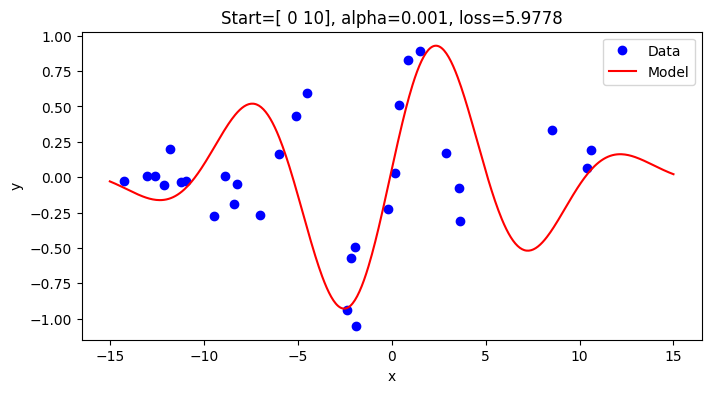

Start=[ 0 10], alpha=0.01, final loss=4.405406, final phi=[ 0.14766616 10.9154898 ]


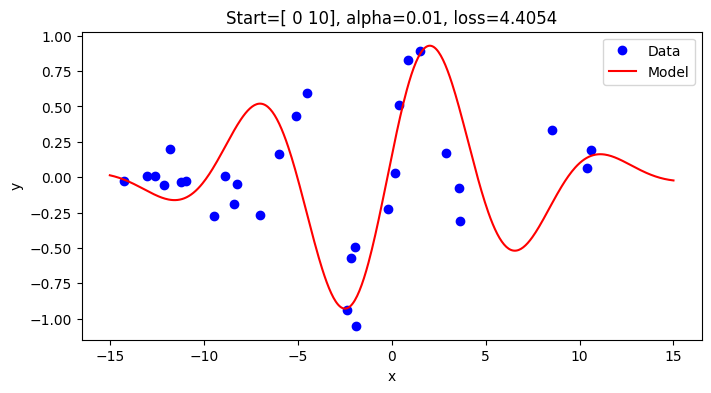

Start=[ 0 10], alpha=0.1, final loss=0.919917, final phi=[ 0.05680591 14.44966617]


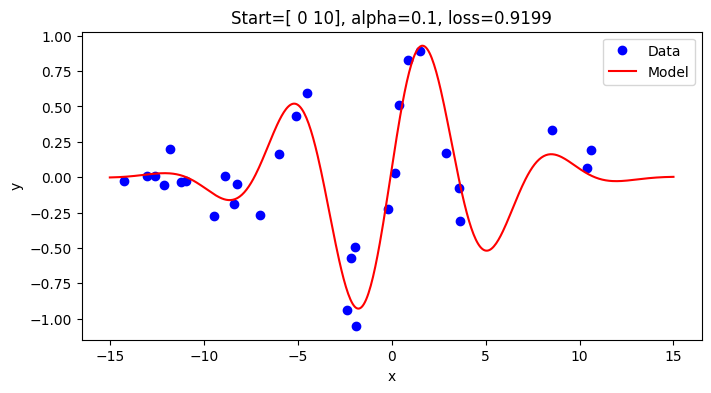

Start=[-5 25], alpha=0.001, final loss=5.431253, final phi=[-430.491   25.   ]


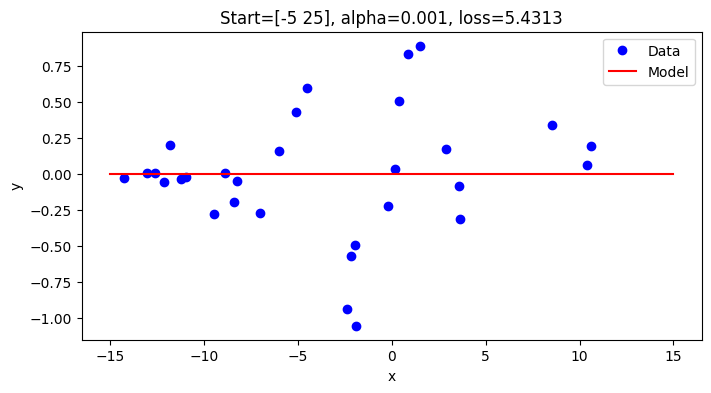

Start=[-5 25], alpha=0.01, final loss=5.431253, final phi=[-4259.91    25.  ]


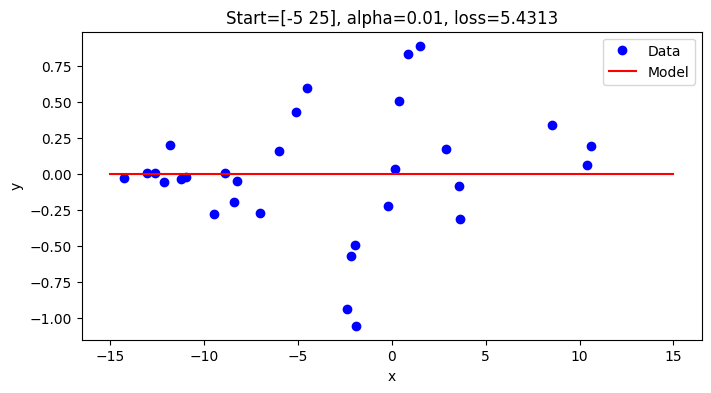

Start=[-5 25], alpha=0.1, final loss=5.431253, final phi=[-4.25541e+04  2.50000e+01]


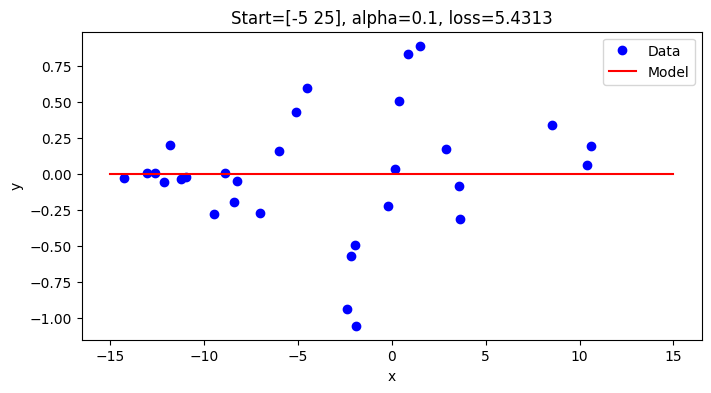

Start=[ 5 15], alpha=0.001, final loss=6.454372, final phi=[ 5.25591125 15.00876846]


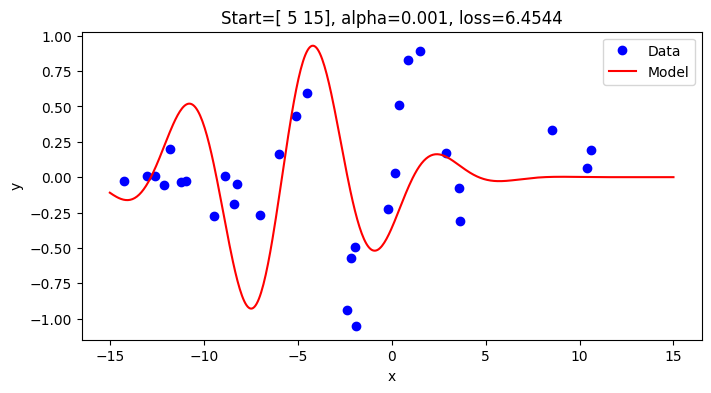

Start=[ 5 15], alpha=0.01, final loss=5.171786, final phi=[ 5.76203394 15.39710081]


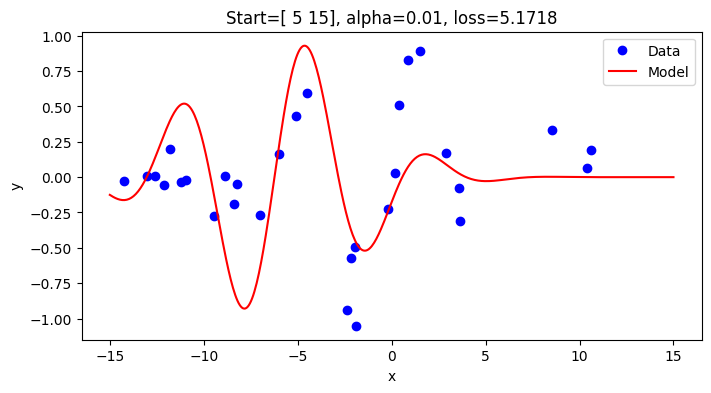

Start=[ 5 15], alpha=0.1, final loss=3.747316, final phi=[ 6.31578302 17.61537357]


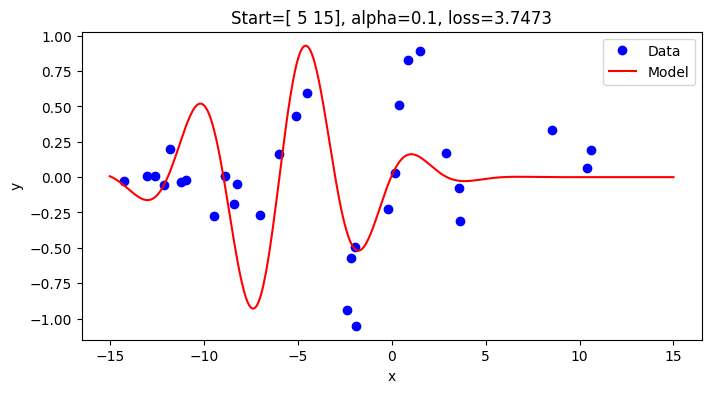

In [21]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Training data (example: Gabor-like)
data = np.array([[-1.920e+00,-1.422e+01,1.490e+00,-1.940e+00,-2.389e+00,-5.090e+00,
                 -8.861e+00,3.578e+00,-6.010e+00,-6.995e+00,3.634e+00,8.743e-01,
                 -1.096e+01,4.073e-01,-9.467e+00,8.560e+00,1.062e+01,-1.729e-01,
                 1.040e+01,-1.261e+01,1.574e-01,-1.304e+01,-2.156e+00,-1.210e+01,
                 -1.119e+01,2.902e+00,-8.220e+00,-1.179e+01,-8.391e+00,-4.505e+00],
                 [-1.051e+00,-2.482e-02,8.896e-01,-4.943e-01,-9.371e-01,4.306e-01,
                 9.577e-03,-7.944e-02 ,1.624e-01,-2.682e-01,-3.129e-01,8.303e-01,
                 -2.365e-02,5.098e-01,-2.777e-01,3.367e-01,1.927e-01,-2.222e-01,
                 6.352e-02,6.888e-03,3.224e-02,1.091e-02,-5.706e-01,-5.258e-02,
                 -3.666e-02,1.709e-01,-4.805e-02,2.008e-01,-1.904e-01,5.952e-01]])

# Gabor-like model
def model(phi, x):
    sin_component = np.sin(phi[0] + 0.06 * phi[1] * x)
    gauss_component = np.exp(-(phi[0] + 0.06 * phi[1] * x)**2 / 32)
    return sin_component * gauss_component

# Compute sum of squared errors
def compute_loss(data_x, data_y, model, phi):
    y_pred = model(phi, data_x)
    loss = np.sum((y_pred - data_y)**2)
    return loss

# Compute gradient w.r.t phi numerically (finite differences)
def compute_gradient(data_x, data_y, phi, delta=1e-5):
    grad = np.zeros_like(phi)
    for i in range(len(phi)):
        phi_delta = phi.copy()
        phi_delta[i] += delta
        grad[i] = (compute_loss(data_x, data_y, model, phi_delta) -
                   compute_loss(data_x, data_y, model, phi)) / delta
    return grad

# Gradient descent step
def gradient_descent_step(phi, data, alpha):
    grad = compute_gradient(data[0,:], data[1,:], phi)
    return phi - alpha * grad

# Stochastic gradient descent step
def stochastic_gradient_descent_step(phi, data, alpha, batch_size):
    n_data = data.shape[1]
    indices = np.random.permutation(n_data)[:batch_size]
    grad = compute_gradient(data[0, indices], data[1, indices], phi)
    return phi - alpha * grad

# Draw model
def draw_model(data, model, phi, title=None):
    x_model = np.linspace(-15, 15, 500)
    y_model = model(phi, x_model)
    plt.figure(figsize=(8,4))
    plt.plot(data[0,:], data[1,:], 'bo', label='Data')
    plt.plot(x_model, y_model, 'r-', label='Model')
    plt.xlabel('x'); plt.ylabel('y')
    if title: plt.title(title)
    plt.legend()
    plt.show()

# --- Experiment settings ---
learning_rates = [0.001, 0.01, 0.1]       # Small, moderate, large
batch_sizes = [1, 5, 30]                  # For SGD: mini-batch vs full batch
n_steps = 50
starting_points = [np.array([0,10]), np.array([-5, 25]), np.array([5, 15])]

# --- Run experiments ---
for phi_start in starting_points:
    for alpha in learning_rates:
        phi = phi_start.copy()
        phi_history = [phi.copy()]
        for step in range(n_steps):
            # Use either gradient descent or SGD
            phi = gradient_descent_step(phi, data, alpha)          # Fixed learning rate GD
            # phi = stochastic_gradient_descent_step(phi, data, alpha, batch_size=5)  # Uncomment for SGD
            phi_history.append(phi.copy())

        final_loss = compute_loss(data[0,:], data[1,:], model, phi)
        print(f"Start={phi_start}, alpha={alpha}, final loss={final_loss:.6f}, final phi={phi.ravel()}")
        draw_model(data, model, phi, title=f"Start={phi_start}, alpha={alpha}, loss={final_loss:.4f}")

In [22]:
# --- Gradient descent with learning rate schedule ---
def gradient_descent_with_schedule(phi, data, alpha, beta=0.5, M=10, n_steps=50):
    """
    phi: initial parameters (numpy array)
    data: training data
    alpha: initial learning rate
    beta: factor to reduce learning rate
    M: reduce learning rate every M steps
    n_steps: total number of steps
    """
    phi_history = [phi.copy()]
    alpha_current = alpha

    for step in range(n_steps):
        # Gradient descent step
        grad = compute_gradient(data[0,:], data[1,:], phi)
        phi = phi - alpha_current * grad
        phi_history.append(phi.copy())

        # Apply learning rate schedule
        if (step + 1) % M == 0:
            alpha_current *= beta
            print(f"Step {step+1}: Reduced learning rate to {alpha_current:.6f}")

    return phi, phi_history